In [1]:
!pip install torchinfo
!pip install --quiet torchview graphviz

In [2]:
import math
import os
import time
from datetime import timedelta
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchinfo import summary
from torchview import draw_graph

import torchvision.models as models

In [3]:
ROOT_DIR = "/kaggle/input/datasets/dreamer07/eyepacs"
BATCH_SIZE = 16
NUM_WORKERS = 4
RANDOM_STATE = 42

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

ROOT_DIR = "/kaggle/input/datasets/dreamer07/eyepacs"
CSV_PATH = "/kaggle/input/datasets/dreamer07/eyepacs/trainLabels.csv/trainLabels.csv"
IMAGE_DIR = "/kaggle/input/datasets/dreamer07/eyepacs/data/data"


# =========================
# EYE-PACS CSV LOADER
# =========================
def load_eyepacs_annotations():

    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"{CSV_PATH} not found")

    df = pd.read_csv(CSV_PATH)

    required_cols = ["image", "level"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    records = []
    missing_images = 0

    for _, row in df.iterrows():
        img_id = str(row["image"]).strip()
        label = int(row["level"])

        img_path = os.path.join(IMAGE_DIR, img_id + ".jpeg")  # ⚠️ eyepacs uses .jpeg

        if os.path.isfile(img_path):
            records.append((img_path, label))
        else:
            missing_images += 1

    df_records = pd.DataFrame(records, columns=["image_path", "label"])

    print("========== DATA SUMMARY ==========")
    print("Loaded images:", len(df_records))
    print("Missing images:", missing_images)
    print("Class distribution:")
    print(df_records["label"].value_counts().sort_index())
    print("==================================")

    return df_records


# LOAD DATA
df_all = load_eyepacs_annotations()

CLASSES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

num_classes = len(CLASSES)

train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

========== DATA SUMMARY ==========
Loaded images: 35126
Missing images: 0
Class distribution:
label
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64

Split sizes:
Train: 24588
Val: 5269
Test: 5269


In [5]:
class EyePACSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
IMG_SIZE = 224 

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
train_dataset = EyePACSDataset(train_df, transform=transform)
val_dataset = EyePACSDataset(val_df, transform=transform)
test_dataset = EyePACSDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

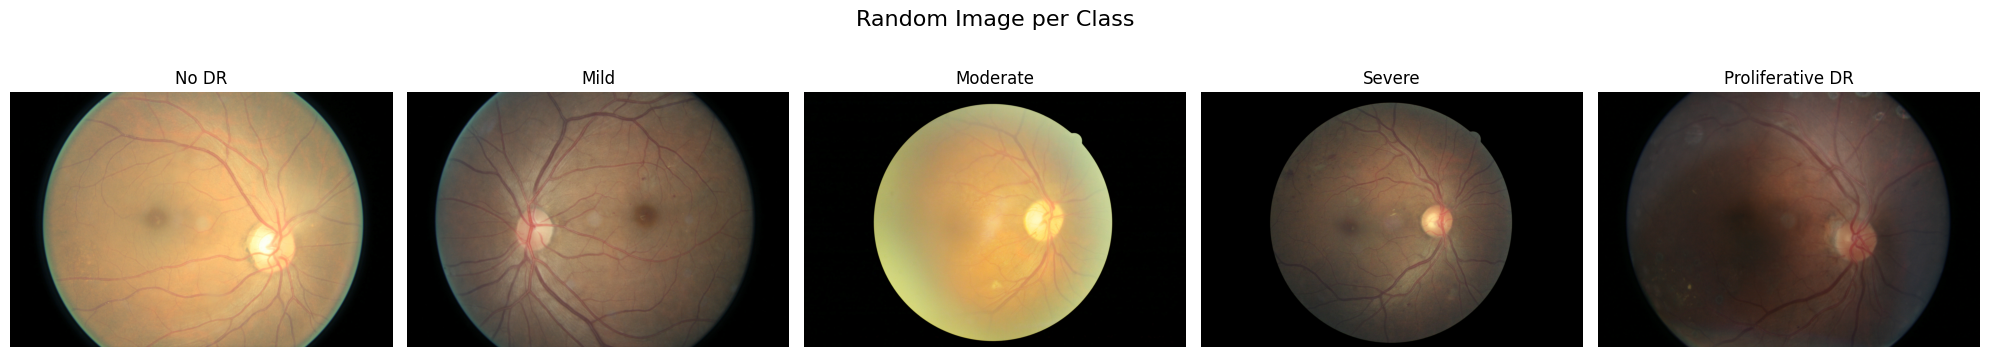

In [8]:
def show_random_images_per_class(df, classes, title="Random Image per Class"):
    num_classes = len(classes)
    fig, axs = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))
    if num_classes == 1:
        axs = [axs]

    for i, cls in enumerate(range(num_classes)):
        class_df = df[df['label'] == cls]
        if len(class_df) == 0:
            axs[i].axis("off")
            axs[i].set_title(f"{classes[cls]}\n(No Images)")
            continue

        row = class_df.sample(n=1).iloc[0]
        image = Image.open(row['image_path']).convert('RGB')
        axs[i].imshow(image)
        axs[i].set_title(classes[cls], fontsize=12)
        axs[i].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
show_random_images_per_class(train_df, CLASSES)

In [24]:
from torchvision import transforms
from torchinfo import summary
from torchview import draw_graph
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from timm.models.vision_transformer import Block

In [25]:
# -----------------------------
# Patch Embedding from Feature Map (Linear projection)
# -----------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, emb_size, cls_token=True, max_patches=1000):
        super().__init__()
        self.cls_token_enabled = cls_token
        self.proj = nn.Linear(in_channels, emb_size)

        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size)) if cls_token else None
        
        # large pos_embed (dynamic slicing later)
        self.pos_embed = nn.Parameter(torch.randn(1, max_patches, emb_size))

    def forward(self, x):
        B, C, H, W = x.shape

        x = x.flatten(2).transpose(1, 2)  # [B, HW, C]
        x = self.proj(x)                 # [B, HW, emb]

        if self.cls_token_enabled:
            cls_tok = self.cls_token.expand(B, -1, -1)
            x = torch.cat((cls_tok, x), dim=1)  # [B, HW+1, emb]

        #  match positional embedding dynamically
        pos_embed = self.pos_embed[:, :x.size(1), :]
        x = x + pos_embed

        return x

# -----------------------------
# Classification Head
# -----------------------------
class MLPHead(nn.Module):
    def __init__(self, emb_size, n_classes):
        super().__init__()
        self.norm = nn.LayerNorm(emb_size)
        self.head = nn.Linear(emb_size, n_classes)

    def forward(self, x):
        return self.head(self.norm(x[:, 0]))  # Class token output

# -----------------------------
# EffiViT using Built-in timm Backbone & ViT Blocks
# -----------------------------
class EffiViT(nn.Module):
    def __init__(self,
                 emb_size=768,
                 depth=6,
                 num_heads=8,
                 mlp_ratio=4.0,
                 dropout=0.1,
                 drop_path=0.0,
                 n_classes=20,
                 freeze_backbone=True):
        super().__init__()

        # Use EfficientNet B4 from timm (features_only=True to get feature maps)
        self.backbone = timm.create_model("efficientnet_b4", features_only=True, pretrained=True)
        self.out_channels = self.backbone.feature_info[-1]['num_chs']  # 1792

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Patch Embedding from last EfficientNet feature map
        self.patch_embed = PatchEmbedding(
            in_channels=self.out_channels,
            emb_size=emb_size,
            cls_token=True
        )

        # Transformer Encoder blocks (from timm)
        self.transformer = nn.Sequential(*[
            Block(
                dim=emb_size,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=True,
                drop_path=drop_path,
                act_layer=nn.GELU,
                norm_layer=nn.LayerNorm
            )
            for _ in range(depth)
        ])

        self.head = MLPHead(emb_size, n_classes)

    def forward(self, x):
        features = self.backbone(x)[-1]  # Output from last feature stage: [B, 1792, 7, 7]
        x = self.patch_embed(features)   # [B, N+1, emb_size]
        x = self.transformer(x)          # [B, N+1, emb_size]
        x = self.head(x)                 # [B, n_classes]
        return x

In [27]:
import timm
import torch
import torch.nn as nn
from torchinfo import summary

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EffiViT(n_classes=num_classes)  # for RGB input
summary(model, input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"])

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
EffiViT                                            [1, 3, 224, 224]          [1, 5]                    --                        Partial
├─EfficientNetFeatures: 1-1                        [1, 3, 224, 224]          [1, 24, 112, 112]         --                        False
│    └─Conv2d: 2-1                                 [1, 3, 224, 224]          [1, 48, 112, 112]         (1,296)                   False
│    └─BatchNormAct2d: 2-2                         [1, 48, 112, 112]         [1, 48, 112, 112]         96                        False
│    │    └─Identity: 3-1                          [1, 48, 112, 112]         [1, 48, 112, 112]         --                        --
│    │    └─SiLU: 3-2                              [1, 48, 112, 112]         [1, 48, 112, 112]         --                        --
│    └─Sequential: 2-3                             --  

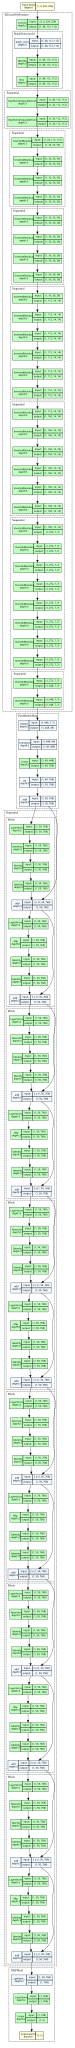

In [28]:
from torchview import draw_graph
from IPython.display import SVG, display

dummy_input = torch.randn(1, 3, 224, 224).to(device)

model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True
)

svg = model_graph.visual_graph.pipe(format='svg')

display(SVG(svg))

with open("/kaggle/working/model_graph.svg", "wb") as f:
    f.write(svg)

In [29]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()

    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)

    precision = precision_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    recall = recall_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    f1 = f1_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    num_classes = y_pred.shape[1]
    auc_scores = []

    for class_idx in range(num_classes):
        class_y_true = (y_true_numpy == class_idx).astype(np.float32)
        class_y_pred = y_pred[:, class_idx].cpu().numpy()

        if np.unique(class_y_true).size < 2:
            continue

        try:
            auc_score = roc_auc_score(class_y_true, class_y_pred)
            auc_scores.append(auc_score)
        except ValueError:
            continue

    auc_avg = np.mean(auc_scores) if auc_scores else 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc_avg,
    }

    return metrics

In [30]:
# Hyperparameters
num_epochs = 20
initial_lr = 0.0005

# Criterion, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# Plateau LR scheduler (fixed — no verbose arg)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.75,
    patience=5
)

In [31]:
# ===== METRICS TRACKING =====
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score", "auc"]

train_metrics_history = {metric: [] for metric in metric_names}
val_metrics_history = {metric: [] for metric in metric_names}

# ===== EARLY STOPPING SETUP =====
best_val_loss = float("inf")
epochs_no_improve = 0
patience = 5

# ===== TRAINING LOOP =====
for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    total_train_loss = 0.0
    all_train_predictions = []
    all_train_targets = []

    for data, targets in tqdm(train_loader, desc=f"Training Epoch [{epoch+1}/{num_epochs}]"):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)

    train_metrics = custom_metrics(
        torch.tensor(np.array(all_train_predictions)),
        torch.tensor(np.array(all_train_targets)),
        avg_train_loss
    )

    print("\nTrain Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()]))

    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])


    # ================= VALIDATION =================
    model.eval()
    total_val_loss = 0.0
    all_val_predictions = []
    all_val_targets = []

    with torch.no_grad():
        for data, targets in tqdm(val_loader, desc="Validating Model"):
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            total_val_loss += loss.item()

            all_val_predictions.extend(outputs.detach().cpu().numpy())
            all_val_targets.extend(targets.detach().cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    val_metrics = custom_metrics(
        torch.tensor(np.array(all_val_predictions)),
        torch.tensor(np.array(all_val_targets)),
        avg_val_loss
    )

    print("Val Metrics   - " + ", ".join([f"{k}: {v:.4f}" for k, v in val_metrics.items()]))

    for metric in metric_names:
        val_metrics_history[metric].append(val_metrics[metric])


    # ================= SAVE BEST MODEL ===============
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0  # reset counter

        torch.save(model.state_dict(),
                   "/kaggle/working/best_model_weights.pth")

        torch.save(model,
                   "/kaggle/working/best_model_full.pth")

        print("✅ Best model saved")

    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epoch(s)")

        # ================= EARLY STOPPING ================
        if epochs_no_improve >= patience:
            print(f"\n🛑 Early stopping triggered after {epoch+1} epochs")
            break


    # ================= SCHEDULER =================
    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} — ValLoss: {avg_val_loss:.4f} — LR: {current_lr:.6f}")


Training Epoch [1/20]: 100%|██████████| 1537/1537 [16:22<00:00,  1.56it/s]



Train Metrics - loss: 0.8667, accuracy: 0.7327, precision: 0.5996, recall: 0.7327, f1_score: 0.6302, auc: 0.6004


Validating Model: 100%|██████████| 330/330 [03:28<00:00,  1.58it/s]


Val Metrics   - loss: 0.8620, accuracy: 0.7347, precision: 0.5439, recall: 0.7347, f1_score: 0.6230, auc: 0.6529
✅ Best model saved
Epoch 1/20 — ValLoss: 0.8620 — LR: 0.000500


Training Epoch [2/20]: 100%|██████████| 1537/1537 [16:08<00:00,  1.59it/s]


...

Val Metrics   - loss: 0.8162, accuracy: 0.7360, precision: 0.6236, recall: 0.7360, f1_score: 0.6263, auc: 0.6985
⚠️ No improvement for 4 epoch(s)
Epoch 6/20 — ValLoss: 0.8162 — LR: 0.000500


Training Epoch [7/20]: 100%|██████████| 1537/1537 [16:06<00:00,  1.59it/s]



Train Metrics - loss: 0.8140, accuracy: 0.7350, precision: 0.5995, recall: 0.7350, f1_score: 0.6300, auc: 0.6684


Validating Model: 100%|██████████| 330/330 [03:21<00:00,  1.64it/s]


Val Metrics   - loss: 0.8201, accuracy: 0.7345, precision: 0.5459, recall: 0.7345, f1_score: 0.6256, auc: 0.6459
⚠️ No improvement for 5 epoch(s)

🛑 Early stopping triggered after 7 epochs


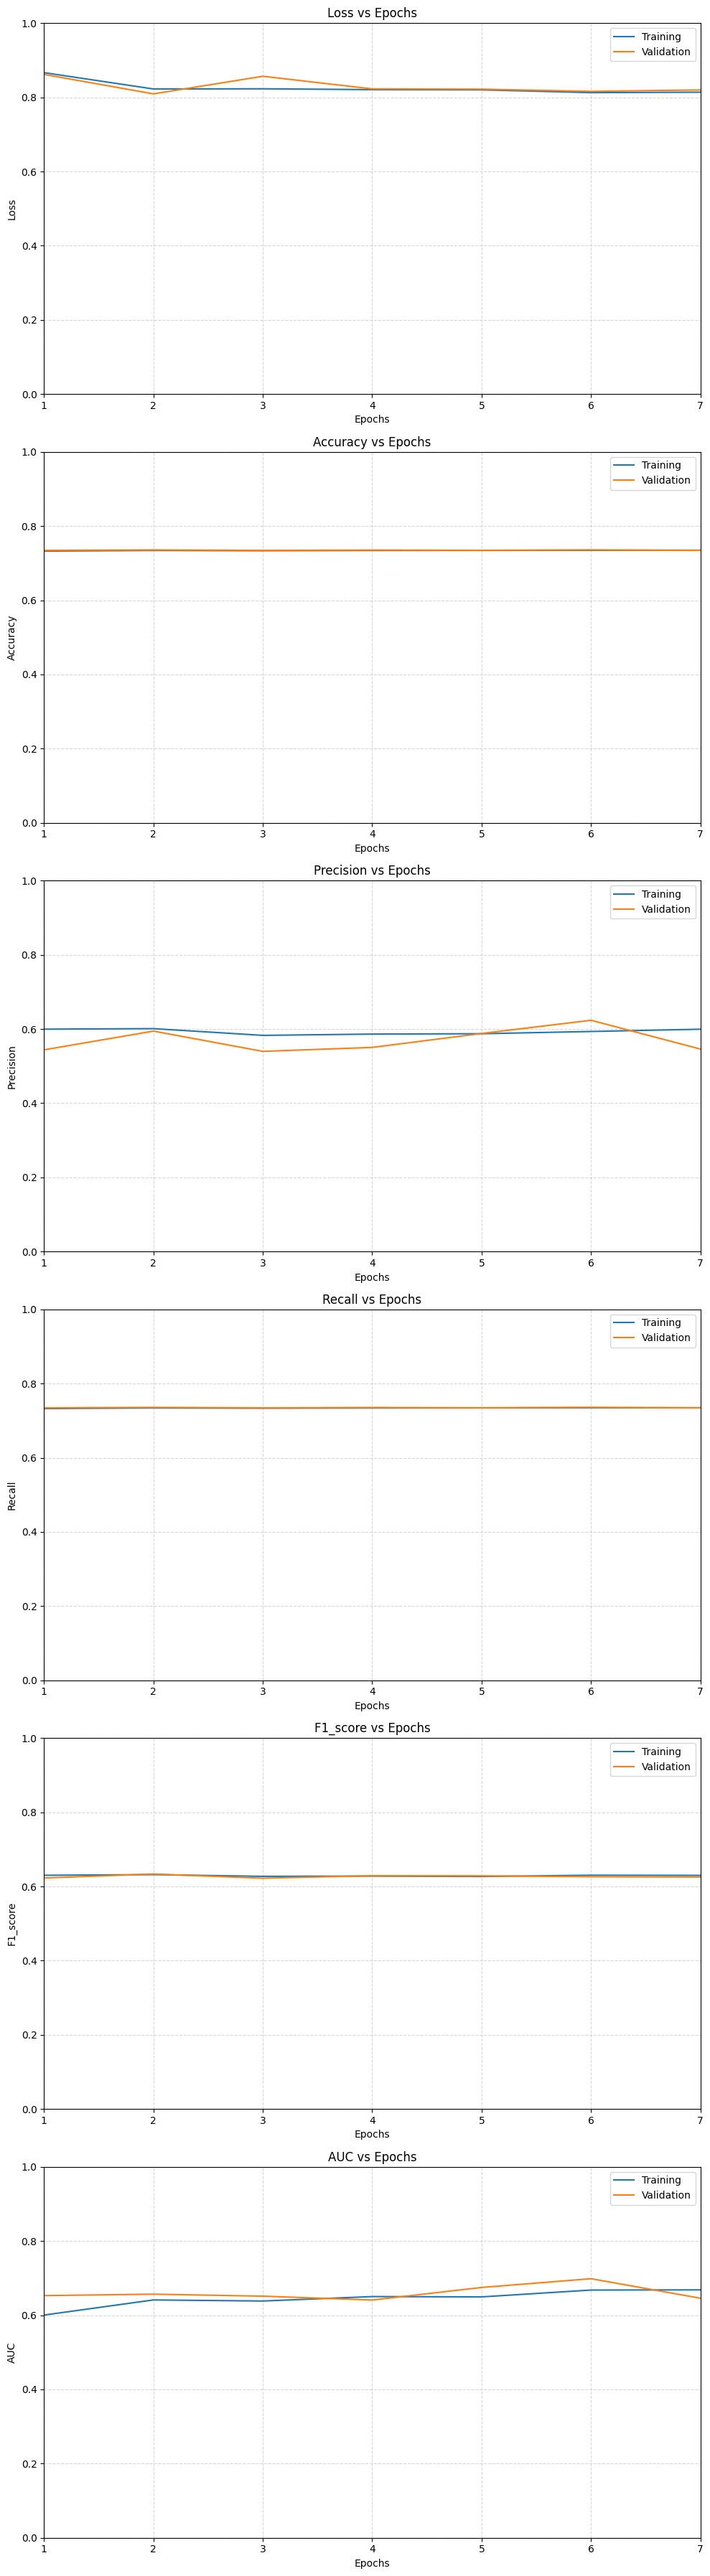

In [32]:
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))
    if num_metrics == 1:
        axes = [axes]

    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics_history[metric_name]
        val_metric = val_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name == "auc":
            ax.set_ylabel("AUC")
            ax.set_title("AUC vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)

        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()


plot_metrics(train_metrics_history, val_metrics_history, metric_names)

In [33]:
state_dict = torch.load("/kaggle/working/best_model_weights.pth")

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Best model loaded successfully")

✅ Best model loaded successfully


In [34]:
model.eval()
total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="Testing Model")):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.detach().cpu().numpy())
        all_test_targets.extend(targets.detach().cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)

test_metrics = custom_metrics(
    torch.tensor(all_test_predictions),
    torch.tensor(all_test_targets),
    average_test_loss
)

testing_metrics_line = "Test Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in test_metrics.items()])
print(testing_metrics_line)

Testing Model: 100%|██████████| 330/330 [04:31<00:00,  1.21it/s]

Test Metrics - loss: 0.8069, accuracy: 0.7362, precision: 0.5959, recall: 0.7362, f1_score: 0.6351, auc: 0.6624


In [35]:
true_labels = np.array(all_test_targets)
predicted_labels = np.argmax(np.array(all_test_predictions), axis=1)

true_labels = true_labels.astype(int)
predicted_labels = predicted_labels.astype(int)

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASSES,
    digits=4
)

accuracy = accuracy_score(true_labels, predicted_labels)
num_errors = np.sum(true_labels != predicted_labels)

print(report)
print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')

                  precision    recall  f1-score   support

           No DR     0.7434    0.9943    0.8507      3872
            Mild     0.0000    0.0000    0.0000       366
        Moderate     0.3295    0.0365    0.0658       794
          Severe     0.0000    0.0000    0.0000       131
Proliferative DR     0.0000    0.0000    0.0000       106

        accuracy                         0.7362      5269
       macro avg     0.2146    0.2062    0.1833      5269
    weighted avg     0.5959    0.7362    0.6351      5269

There were 1390 errors in 5269 tests for an accuracy of  73.62%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
